## 添加数据集快捷方式

如下图所示，将共享文件夹添加到"我的云端硬盘"。这样colab可以挂载数据集

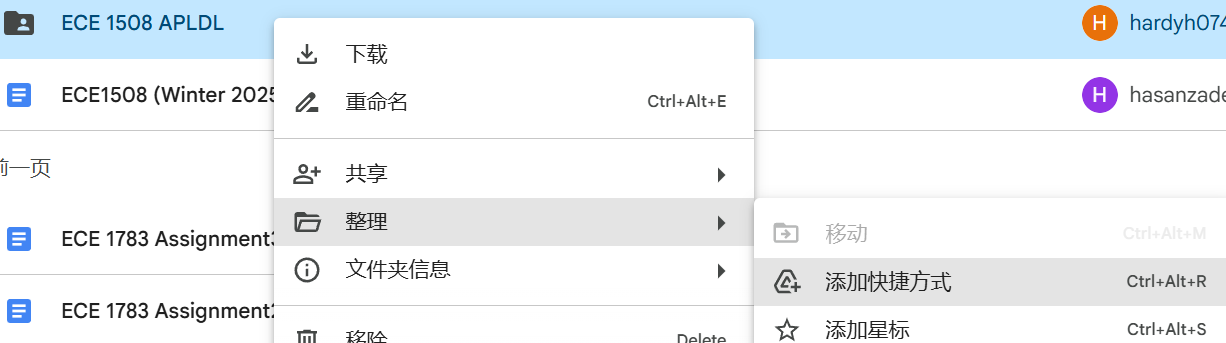

## 加载并解压数据集


只读模式挂载谷歌云盘

In [1]:
from google.colab import drive
drive.mount('/content/drive', readonly=True)

Mounted at /content/drive


创建5个G的内存文件系统加速解压

In [2]:
import os
import subprocess

ramdisk_path = '/content/ramdisk'
ramdisk_size_mb = 5192  # 4GB, adjust as needed

# Create the directory for the ramdisk if it doesn't exist
os.makedirs(ramdisk_path, exist_ok=True)

# Mount the ramdisk
try:
    # Check if the ramdisk is already mounted
    mount_check = subprocess.run(f'mount | grep {ramdisk_path}', shell=True, capture_output=True, text=True)
    if ramdisk_path not in mount_check.stdout:
        subprocess.run(f'sudo mount -t tmpfs -o size={ramdisk_size_mb}m tmpfs {ramdisk_path}', shell=True, check=True)
        print(f"Ramdisk of {ramdisk_size_mb}MB created and mounted at {ramdisk_path}")
    else:
        print(f"Ramdisk already mounted at {ramdisk_path}")
except subprocess.CalledProcessError as e:
    print(f"Error creating or mounting ramdisk: {e.stderr}")
    print("Falling back to default output directory: ./tmp")
    ramdisk_path = './tmp'


Ramdisk of 5192MB created and mounted at /content/ramdisk


开始解压

In [4]:
file_path = '/content/drive/My Drive/ECE 1508 APLDL/dataset/OCT_clean.tar' # Assuming the file is now .tar.gz
output_directory = ramdisk_path # This is where the 'OCT_clean' directory will be created

print("Starting extraction...")
# Extract the .tar.gz file from local storage
# Use -x for extract, -z for gzip compression, -f for file, and -C for changing directory
!tar -xf "{file_path}" -C "{output_directory}"

print("Extraction complete.")

Starting extraction...
Extraction complete.


## 查看数据集大小

In [5]:
!du -sh /content/ramdisk

4.3G	/content/ramdisk


## 删除数据集

In [6]:
!sudo umount /content/ramdisk

In [8]:
!rmdir "{output_directory}"